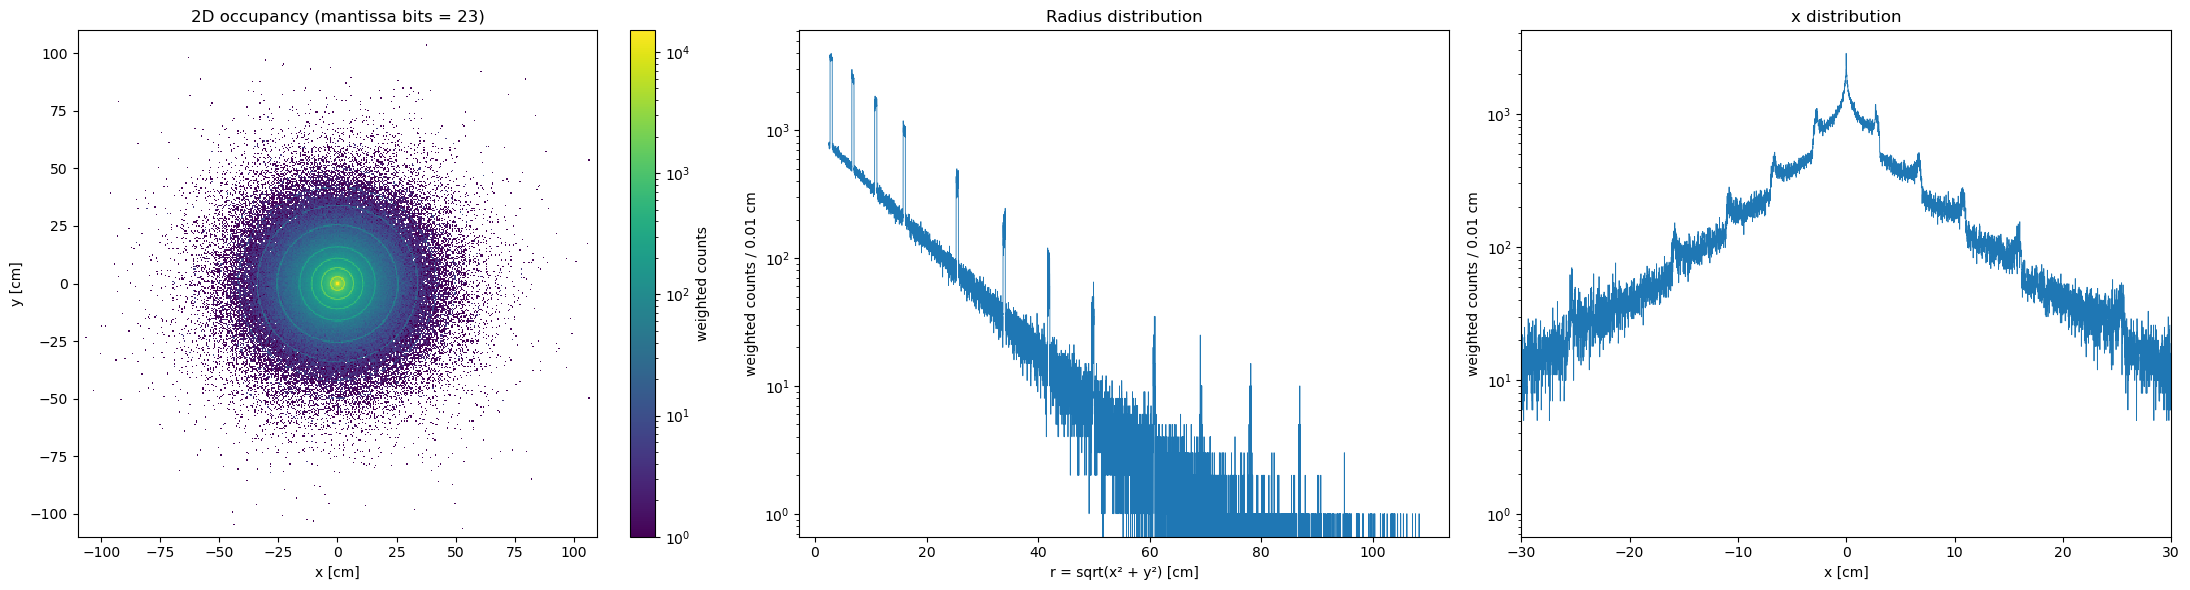

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

# --- Mantissa reduction (float32) with bitmasks, no hex ---
def reduce_mantissa_f32_nohex(x, nbits=10, keep_nans=True):
    MANT_BITS = 23
    EXP_BITS  = 8
    SIGN_BIT  = 31

    if not (0 <= nbits <= MANT_BITS):
        raise ValueError(f"nbits must be in [0, {MANT_BITS}] for float32")

    a = np.asarray(x, dtype=np.float32)
    u = a.view(np.uint32)

    mant_mask = (np.uint32(1) << MANT_BITS) - np.uint32(1)
    exp_mask  = ((np.uint32(1) << EXP_BITS) - np.uint32(1)) << MANT_BITS
    sign_mask = np.uint32(1) << SIGN_BIT

    if keep_nans:
        exp_field  = (u & exp_mask) >> MANT_BITS
        mant_field = u & mant_mask
        is_nan = (exp_field == ((np.uint32(1) << EXP_BITS) - np.uint32(1))) & (mant_field != 0)
    else:
        is_nan = np.zeros_like(u, dtype=bool)

    if nbits == MANT_BITS:
        out_u = u
    else:
        drop = MANT_BITS - nbits
        low_bits_mask = (np.uint32(1) << drop) - np.uint32(1) if drop > 0 else np.uint32(0)
        keep_mant_mask = mant_mask & ~low_bits_mask

        sign_exp = u & (sign_mask | exp_mask)
        mant_q   = (u & mant_mask) & keep_mant_mask
        out_u    = sign_exp | mant_q

        if keep_nans:
            out_u = np.where(is_nan, u, out_u)

    return out_u.view(np.float32)

# --- CMS Phase-1 barrel layer radii (cm) ---
radii_cm = np.array([
    2.9, 6.8, 10.9, 16.0,               # Pixel barrel L1-L4
    25.5, 33.9, 41.9, 49.8,             # TIB L1-L4
    60.8, 69.2, 78.0, 86.8, 96.5, 108.0 # TOB L1-L6
], dtype=np.float32)

# --- Simulation parameters (ALL IN CM) ---
thickness_cm = 0.4          # 4 mm = 0.4 cm
half_t = thickness_cm / 2.0
rng = np.random.default_rng(12345)

# --- Exponential-only sampling (main population) ---
N_EXP = 1_000_000
r_exp = rng.exponential(scale=10.0, size=N_EXP).astype(np.float32)  # 10 cm scale
theta = rng.uniform(0.0, 2.0 * np.pi, size=N_EXP).astype(np.float32)

x_true = (r_exp * np.cos(theta)).astype(np.float32)
y_true = (r_exp * np.sin(theta)).astype(np.float32)

# --- Weight = 5 if point falls in ANY material annulus, else 1 ---
in_material = np.zeros(N_EXP, dtype=bool)
for R in radii_cm:
    in_material |= (r_exp >= (R - half_t)) & (r_exp <= (R + half_t))

w_true = np.where(in_material, 5.0, 1.0).astype(np.float32)

# --- Histogram settings (CM) ---
xy_range = 110.0     # cm
bins2d = 400

binw = 0.01          # cm
rmin = float(np.min(radii_cm) - half_t - 0.2)
rmax = float(np.max(radii_cm) + half_t + 0.2)
rbins = np.arange(rmin, rmax + binw, binw, dtype=np.float64)

# --- Make plots for mantissa bits ---
for nbits in range(23, 24):
    xq = reduce_mantissa_f32_nohex(x_true, nbits=nbits)
    yq = reduce_mantissa_f32_nohex(y_true, nbits=nbits)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # ------------------------------------------------------------------
    # Panel 1: 2D histogram (x,y)
    # ------------------------------------------------------------------
    h = axes[0].hist2d(
        xq, yq,
        bins=bins2d,
        range=[[-xy_range, xy_range], [-xy_range, xy_range]],
        weights=w_true,
        norm=matplotlib.colors.LogNorm()
    )
    axes[0].set_xlabel("x [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title(f"2D occupancy (mantissa bits = {nbits})")

    cbar = fig.colorbar(h[3], ax=axes[0])
    cbar.set_label("weighted counts")

    # ------------------------------------------------------------------
    # Panel 2: 1D radius histogram (step)
    # ------------------------------------------------------------------
    rq = np.sqrt(xq**2 + yq**2)
    counts_r, edges_r = np.histogram(rq, bins=rbins, weights=w_true)
    centers_r = 0.5 * (edges_r[:-1] + edges_r[1:])

    axes[1].step(centers_r, counts_r, where="mid", lw=0.6)
    axes[1].set_xlabel("r = sqrt(x² + y²) [cm]")
    axes[1].set_ylabel(f"weighted counts / {binw} cm")
    axes[1].set_yscale("log")
    axes[1].set_title("Radius distribution")

    # ------------------------------------------------------------------
    # Panel 3: 1D x histogram (step)
    # ------------------------------------------------------------------
    xbins = np.arange(-xy_range, xy_range + binw, binw, dtype=np.float64)
    counts_x, edges_x = np.histogram(xq, bins=xbins, weights=w_true)
    centers_x = 0.5 * (edges_x[:-1] + edges_x[1:])

    axes[2].step(centers_x, counts_x, where="mid", lw=0.6)
    axes[2].set_xlabel("x [cm]")
    axes[2].set_ylabel(f"weighted counts / {binw} cm")
    axes[2].set_yscale("log")
    axes[2].set_xlim(-30, 30)
    axes[2].set_title("x distribution")

    plt.tight_layout()
    plt.show()
